In [1]:
from constants import users_list, data_path
from lib import spoti, genre_normalizer, plotting, preprocessing, dimensionality_reduction, user_similarities

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import json
import os
from sklearn.decomposition import PCA
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from torch.nn import functional as F
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
from sklearn.metrics import mean_squared_error
import random
import time
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors, NeighborhoodComponentsAnalysis
from sklearn.metrics import pairwise_distances
import pickle
import numpy as np
from typing import List, Dict, Tuple, Optional, Any, Callable
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from IPython.display import display, HTML
from lib.matrix_dataset import MatrixDataset
from recommenders.vae import MultiVAE
from recommenders.metrics import NDCG_binary_at_k_batch, Recall_at_k_batch_torch, mpr
import datetime

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float32

if torch.backends.mps.is_available():
    mps_device = torch.device("mps")
    device = mps_device
    x = torch.ones(1, device=mps_device)
    print(x)
else:
    print ("MPS device not found.")

if device == torch.device("cuda"):
    dtype = torch.float32
    print("Using CUDA.")
elif device == torch.device("cpu"):
    dtype = torch.float64
    print("Using CPU.")
elif device == torch.device("mps"):
    dtype = torch.float32
    print("Using MPS.")

# device = "cpu"
# dtype = torch.float32

tensor([1.], device='mps:0')
Using MPS.


# Import data

In [3]:
df = spoti.load_all_tracks(
    base_path=data_path.DATA_PATH,
    users=users_list.USERS,
    top_tracks_affinity_start = {
        "short_term": 1.0,
        "medium_term": 1.0,
        "long_term": 1.0,
    },
    top_tracks_affinity_end = {
        "short_term": 0,
        "medium_term": 0,
        "long_term": 0,
    },
    top_tracks_include_end=False,
    liked_tracks_start_affinity=1.0,
    liked_tracks_end_affinity=0.1,
    liked_tracks_include_endpoint=False,
    load_spotify_tracks=False,
    playlists_affinity=0.2,
)
df

,album,artists,available_markets,disc_number,duration_ms,explicit,external_ids,external_urls,href,id,...,time_range,affinity,username,release_year,normalized_genres,added_at,episode,track,added_by,playlist_id
0,"{'album_type': 'SINGLE', 'artists': [{'externa...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,196426,False,{'isrc': 'USSM12301260'},{'spotify': 'https://open.spotify.com/track/75...,https://api.spotify.com/v1/tracks/75rqqKvzJCGv...,75rqqKvzJCGv2oq9C4yFDt,...,medium_term,1.00,daniel,2023,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
1,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,137533,True,{'isrc': 'USSM12109218'},{'spotify': 'https://open.spotify.com/track/2F...,https://api.spotify.com/v1/tracks/2FYGZDfsAnNs...,2FYGZDfsAnNsrm1gVbyKnG,...,medium_term,0.98,daniel,2022,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
2,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,162906,True,{'isrc': 'USSM12109222'},{'spotify': 'https://open.spotify.com/track/4k...,https://api.spotify.com/v1/tracks/4kroNlz8BTfs...,4kroNlz8BTfswE4M0i3YCh,...,medium_term,0.96,daniel,2022,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
3,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,89749,False,{'isrc': 'USSM12208854'},{'spotify': 'https://open.spotify.com/track/2N...,https://api.spotify.com/v1/tracks/2N3YZ075lq9z...,2N3YZ075lq9z1ObaAiX6l1,...,medium_term,0.94,daniel,2022,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
4,"{'album_type': 'SINGLE', 'artists': [{'externa...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,174044,False,{'isrc': 'USSM12300114'},{'spotify': 'https://open.spotify.com/track/2S...,https://api.spotify.com/v1/tracks/2SiAcexM2p1y...,2SiAcexM2p1yX6joESbehd,...,medium_term,0.92,daniel,2023,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10230,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AL, AM, AT, AZ, BA, BE, BG, BY, CH, CW, C...",1,251880,False,{'isrc': 'GBN9Y1100001'},{'spotify': 'https://open.spotify.com/track/3z...,https://api.spotify.com/v1/tracks/3z7dWKRsjDNM...,3z7dWKRsjDNM24ohLKZBnA,...,NaN,0.20,todd,1967,"[rock, rock, rock, rock, rock, rock, rock]",2022-12-30 08:42:31+00:00,False,True,ssscnm71jg9pv7fryho4d5qgs,674vFKUXNUjlUxXhAnQvG9
10231,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,193853,False,{'isrc': 'GBLTP1700005'},{'spotify': 'https://open.spotify.com/track/1V...,https://api.spotify.com/v1/tracks/1VofMhhL98pe...,1VofMhhL98pewltVGBSmCW,...,NaN,0.20,todd,2017,"[rock, rock, rock, rock, rock]",2020-08-10 14:53:07+00:00,False,True,ssscnm71jg9pv7fryho4d5qgs,674vFKUXNUjlUxXhAnQvG9
10232,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,295493,False,{'isrc': 'GBLTP1700011'},{'spotify': 'https://open.spotify.com/track/0K...,https://api.spotify.com/v1/tracks/0KE7apgczHNY...,0KE7apgczHNYiXIvMUY0Fc,...,NaN,0.20,todd,2017,"[rock, rock, rock, rock, rock]",2020-08-10 14:53:13+00:00,False,True,ssscnm71jg9pv7fryho4d5qgs,674vFKUXNUjlUxXhAnQvG9
10233,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,467306,False,{'isrc': 'GBLTP1700014'},{'spotify': 'https://open.spotify.com/track/6v...,https://api.spotify.com/v1/tracks/6vbRA9yAAgIX...,6vbRA9yAAgIXtDlmhyNqPq,...,Na

In [4]:
df = pd.read_csv(os.path.join(data_path.DATA_PATH, "artificial_data.csv"), index_col=0)
df["type"] = "top_track"
spoti.NUMERICAL_FEATURES = ["danceability", "instrumentalness", "duration_ms"]
spoti.PRETTY_PRINT_FEATURES = ["username", "id", "danceability", "instrumentalness", "duration_ms"]
df

,id,username,danceability,duration_ms,instrumentalness,affinity,type
0,Skill,Matthew Valencia,0.168972,0.393010,0.107700,0.277396,top_track
1,Simply some,Matthew Valencia,0.602153,0.281286,0.360737,0.305182,top_track
2,Practice,Matthew Valencia,0.102147,0.214526,0.117687,0.392138,top_track
3,Product,Matthew Valencia,0.071125,0.080618,0.131655,0.108841,top_track
4,Professional,Matthew Valencia,0.429718,0.285770,0.298749,0.086235,top_track
...,...,...,...,...,...,...,...
49995,Church life,Michael Ramirez Jr.,0.167156,0.393468,0.174675,0.099820,top_track
49996,Couple leave,Michael Ramirez Jr.,0.596482,0.009788,0.066215,0.061900,top_track
49997,Reason early,Michael Ramirez Jr.,0.046132,0.186828,0.395730,0.033652,top_track
49998,One send from,Michael Ramirez Jr.,0.315609,0.304490,0.579923,0.100289,top_track


## Setup the dataset

In [5]:
df_matrix_mf = df.copy()
df_matrix_mf.drop_duplicates(subset=["username", "id"], inplace=True) # A user can have multiple entries for the same track (if it's in multiple playlists)
df_matrix_mf.loc[df_matrix_mf["type"] == "liked_track", "affinity"] = 0.5
df_matrix_mf.loc[df_matrix_mf["type"] == "playlist", "affinity"] = 0.3

used_types = ["top_track", "liked_track", "playlist"]
# used_types = ["top_track"]
df_matrix_mf = df_matrix_mf[df["type"].isin(used_types)]
df_matrix_mf["id"] = df_matrix_mf["id"].astype("category")
df_matrix_mf["username"] = df_matrix_mf["username"].astype("category")
df_matrix_mf

/var/folders/jy/ts_mdpfs04d36f2cz44nqbl00000gn/T/ipykernel_2713/1256999401.py:8: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_matrix_mf = df_matrix_mf[df["type"].isin(used_types)]


,id,username,danceability,duration_ms,instrumentalness,affinity,type
0,Skill,Matthew Valencia,0.168972,0.393010,0.107700,0.277396,top_track
1,Simply some,Matthew Valencia,0.602153,0.281286,0.360737,0.305182,top_track
2,Practice,Matthew Valencia,0.102147,0.214526,0.117687,0.392138,top_track
3,Product,Matthew Valencia,0.071125,0.080618,0.131655,0.108841,top_track
4,Professional,Matthew Valencia,0.429718,0.285770,0.298749,0.086235,top_track
...,...,...,...,...,...,...,...
49995,Church life,Michael Ramirez Jr.,0.167156,0.393468,0.174675,0.099820,top_track
49996,Couple leave,Michael Ramirez Jr.,0.596482,0.009788,0.066215,0.061900,top_track
49997,Reason early,Michael Ramirez Jr.,0.046132,0.186828,0.395730,0.033652,top_track
49998,One send from,Michael Ramirez Jr.,0.315609,0.304490,0.579923,0.100289,top_track


In [6]:
df_matrix_mf_filtered = preprocessing.filter_rows_by_min_number_of_occurence(df_matrix_mf, "id", 2)
df_matrix_mf_filtered

,id,username,danceability,duration_ms,instrumentalness,affinity,type
0,Skill,Matthew Valencia,0.168972,0.393010,0.107700,0.277396,top_track
2,Practice,Matthew Valencia,0.102147,0.214526,0.117687,0.392138,top_track
3,Product,Matthew Valencia,0.071125,0.080618,0.131655,0.108841,top_track
4,Professional,Matthew Valencia,0.429718,0.285770,0.298749,0.086235,top_track
5,Science,Matthew Valencia,0.241306,0.487671,0.013941,0.035955,top_track
...,...,...,...,...,...,...,...
49990,Protect,Michael Ramirez Jr.,0.483449,0.092080,0.302563,0.360458,top_track
49991,Support threat,Michael Ramirez Jr.,0.026095,0.291989,0.091185,0.303034,top_track
49993,Describe,Michael Ramirez Jr.,0.036705,0.299850,0.105375,0.256012,top_track
49995,Church life,Michael Ramirez Jr.,0.167156,0.393468,0.174675,0.099820,top_track


In [7]:
df_matrix_mf_filtered["id"] = df_matrix_mf_filtered["id"].cat.remove_unused_categories()
df_matrix_mf_filtered["username"] = df_matrix_mf_filtered["username"].cat.remove_unused_categories()

/var/folders/jy/ts_mdpfs04d36f2cz44nqbl00000gn/T/ipykernel_2713/3495685520.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_matrix_mf_filtered["id"] = df_matrix_mf_filtered["id"].cat.remove_unused_categories()
/var/folders/jy/ts_mdpfs04d36f2cz44nqbl00000gn/T/ipykernel_2713/3495685520.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_matrix_mf_filtered["username"] = df_matrix_mf_filtered["username"].cat.remove_unused_categories()


In [8]:
sparsity, users_count, items_count, interactions_count = preprocessing.compute_sparsity(df_matrix_mf_filtered, "username", "id")
print(f"After filtering, there is {len(users_count)} users, {len(items_count)} items and {len(interactions_count)} interactions, so the sparsity is {sparsity*100:.2f}%.")

After filtering, there is 100 users, 2665 items and 12301 interactions, so the sparsity is 4.62%.


In [9]:
display(users_count)
shuffled_users_df = preprocessing.permute_users(users_count=users_count, seed=42)
display(shuffled_users_df)

username
Cory Hernandez         252
Keith Hodge            245
Sandra Richardson      198
Brian Bowman           188
Michael Ramirez Jr.    185
                      ... 
Steven White            84
Melinda Bradley         82
Mark Wilson             81
Robert Santos           80
Mitchell Jensen         79
Name: count, Length: 100, dtype: int64

,count,old_index
username,,
Mr. John Vazquez,94,Mr. John Vazquez
Hannah Martinez,105,Hannah Martinez
Paula Petersen,98,Paula Petersen
Ann Reed,112,Ann Reed
Russell Schmidt,112,Russell Schmidt
...,...,...
Patrick Simon,102,Patrick Simon
Zachary Sparks,97,Zachary Sparks
Carmen Howard,163,Carmen Howard


In [10]:
train_df, val_df, test_df = preprocessing.split_users_train_validation_test(df_users_shuffled=shuffled_users_df, validation_percentage=0.3, test_percentage=0.2)
print("Original data:")
display(shuffled_users_df)
print("Train data:")
display(train_df)
print("Validation data:")
display(val_df)
print("Test data:")
display(test_df)

Original data:


,count,old_index
username,,
Mr. John Vazquez,94,Mr. John Vazquez
Hannah Martinez,105,Hannah Martinez
Paula Petersen,98,Paula Petersen
Ann Reed,112,Ann Reed
Russell Schmidt,112,Russell Schmidt
...,...,...
Patrick Simon,102,Patrick Simon
Zachary Sparks,97,Zachary Sparks
Carmen Howard,163,Carmen Howard


Train data:


,count,old_index
username,,
Mr. John Vazquez,94,Mr. John Vazquez
Hannah Martinez,105,Hannah Martinez
Paula Petersen,98,Paula Petersen
Ann Reed,112,Ann Reed
Russell Schmidt,112,Russell Schmidt
Jeanne Payne,123,Jeanne Payne
Karen Munoz,149,Karen Munoz
Tracy Jones,95,Tracy Jones
Julia Owens,173,Julia Owens


Validation data:


,count,old_index
username,,
John Martinez,178,John Martinez
Brooke Nunez,100,Brooke Nunez
Joshua Davies,126,Joshua Davies
Michael Evans,91,Michael Evans
Richard Turner,104,Richard Turner
Mitchell Jensen,79,Mitchell Jensen
Kyle Burnett,105,Kyle Burnett
Brooke Orr,113,Brooke Orr
Stephanie Parker,109,Stephanie Parker


Test data:


,count,old_index
username,,
Jessica Lewis,101,Jessica Lewis
Matthew Murphy,93,Matthew Murphy
Michael Brown,125,Michael Brown
Erin Smith,141,Erin Smith
Keith Hodge,245,Keith Hodge
Hayden Moody,105,Hayden Moody
Shane Dennis,150,Shane Dennis
Sandra Richardson,198,Sandra Richardson
Dillon Davis,149,Dillon Davis


Train data:


,id,username,danceability,duration_ms,instrumentalness,affinity,type
0,Skill,Matthew Valencia,0.168972,0.393010,0.107700,0.277396,top_track
2,Practice,Matthew Valencia,0.102147,0.214526,0.117687,0.392138,top_track
3,Product,Matthew Valencia,0.071125,0.080618,0.131655,0.108841,top_track
4,Professional,Matthew Valencia,0.429718,0.285770,0.298749,0.086235,top_track
5,Science,Matthew Valencia,0.241306,0.487671,0.013941,0.035955,top_track
...,...,...,...,...,...,...,...
49990,Protect,Michael Ramirez Jr.,0.483449,0.092080,0.302563,0.360458,top_track
49991,Support threat,Michael Ramirez Jr.,0.026095,0.291989,0.091185,0.303034,top_track
49993,Describe,Michael Ramirez Jr.,0.036705,0.299850,0.105375,0.256012,top_track
49995,Church life,Michael Ramirez Jr.,0.167156,0.393468,0.174675,0.099820,top_track


Validation train data:


,id,username,danceability,duration_ms,instrumentalness,affinity,type
5000,Professional,Amanda Hernandez,0.439894,0.649639,0.335586,0.089389,top_track
5008,Newspaper,Amanda Hernandez,0.220751,0.219137,0.442327,0.539202,top_track
5011,Approach,Amanda Hernandez,0.048629,0.537922,0.062162,0.452637,top_track
5015,Generation,Amanda Hernandez,0.409983,0.122690,0.192258,0.006360,top_track
5080,Think,Amanda Hernandez,0.263793,0.364289,0.436990,0.416278,top_track
...,...,...,...,...,...,...,...
34925,Herself,Wendy Riggs DDS,0.399229,0.030463,0.332645,0.132040,top_track
34951,Customer,Wendy Riggs DDS,0.286606,0.038420,0.401132,0.141005,top_track
34977,Character,Wendy Riggs DDS,0.094072,0.249881,0.371736,0.228545,top_track
34983,Attention,Wendy Riggs DDS,0.084604,0.387017,0.098333,0.364704,top_track


Validation test data:


...

Test train data:


,id,username,danceability,duration_ms,instrumentalness,affinity,type
25013,Forget,Anthony Schwartz,0.406288,0.402971,0.114402,0.157160,top_track
25023,Approach,Anthony Schwartz,0.076666,0.088082,0.053174,0.002936,top_track
25033,Generation,Anthony Schwartz,0.138930,0.082070,0.080019,0.143484,top_track
25059,Process,Anthony Schwartz,0.254058,0.319349,0.320933,0.001067,top_track
25060,Account,Anthony Schwartz,0.700540,0.353046,0.418654,0.603476,top_track
...,...,...,...,...,...,...,...
42431,Opportunity,Zachary Sparks,0.097397,0.004592,0.010200,0.021597,top_track
42455,Citizen,Zachary Sparks,0.327590,0.153620,0.134426,0.116815,top_track
42473,Building,Zachary Sparks,0.032478,0.589925,0.095236,0.101081,top_track
42484,Increase,Zachary Sparks,0.072703,0.431228,0.189193,0.055449,top_track


Test test data:


,id,username,danceability,duration_ms,instrumentalness,affinity,type
25003,Discussion,Anthony Schwartz,0.356463,0.585346,0.135598,0.291504,top_track
25004,Marriage,Anthony Schwartz,0.320403,0.038026,0.191935,0.094295,top_track
25008,Throughout,Anthony Schwartz,0.391797,0.193540,0.187139,0.107142,top_track
25010,Word,Anthony Schwartz,0.482019,0.193703,0.163673,0.175318,top_track
25018,Management,Anthony Schwartz,0.397581,0.107389,0.293166,0.115369,top_track
...,...,...,...,...,...,...,...
42432,Animal,Zachary Sparks,0.384463,0.159128,0.404576,0.134535,top_track
42474,Authority,Zachary Sparks,0.367407,0.216970,0.113760,0.188085,top_track
42480,Matter,Zachary Sparks,0.658043,0.020965,0.044565,0.655692,top_track
42488,Represent,Zachary Sparks,0.453667,0.469862,0.288613,0.388324,top_track


/var/folders/jy/ts_mdpfs04d36f2cz44nqbl00000gn/T/ipykernel_2713/2779665494.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_matrix_mf_filtered[spoti.NUMERICAL_FEATURES] = scaler.transform(df_matrix_mf_filtered[spoti.NUMERICAL_FEATURES])
/var/folders/jy/ts_mdpfs04d36f2cz44nqbl00000gn/T/ipykernel_2713/2779665494.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df[spoti.NUMERICAL_FEATURES] = scaler.transform(train_df[spoti.NUMERICAL_FEATURES])


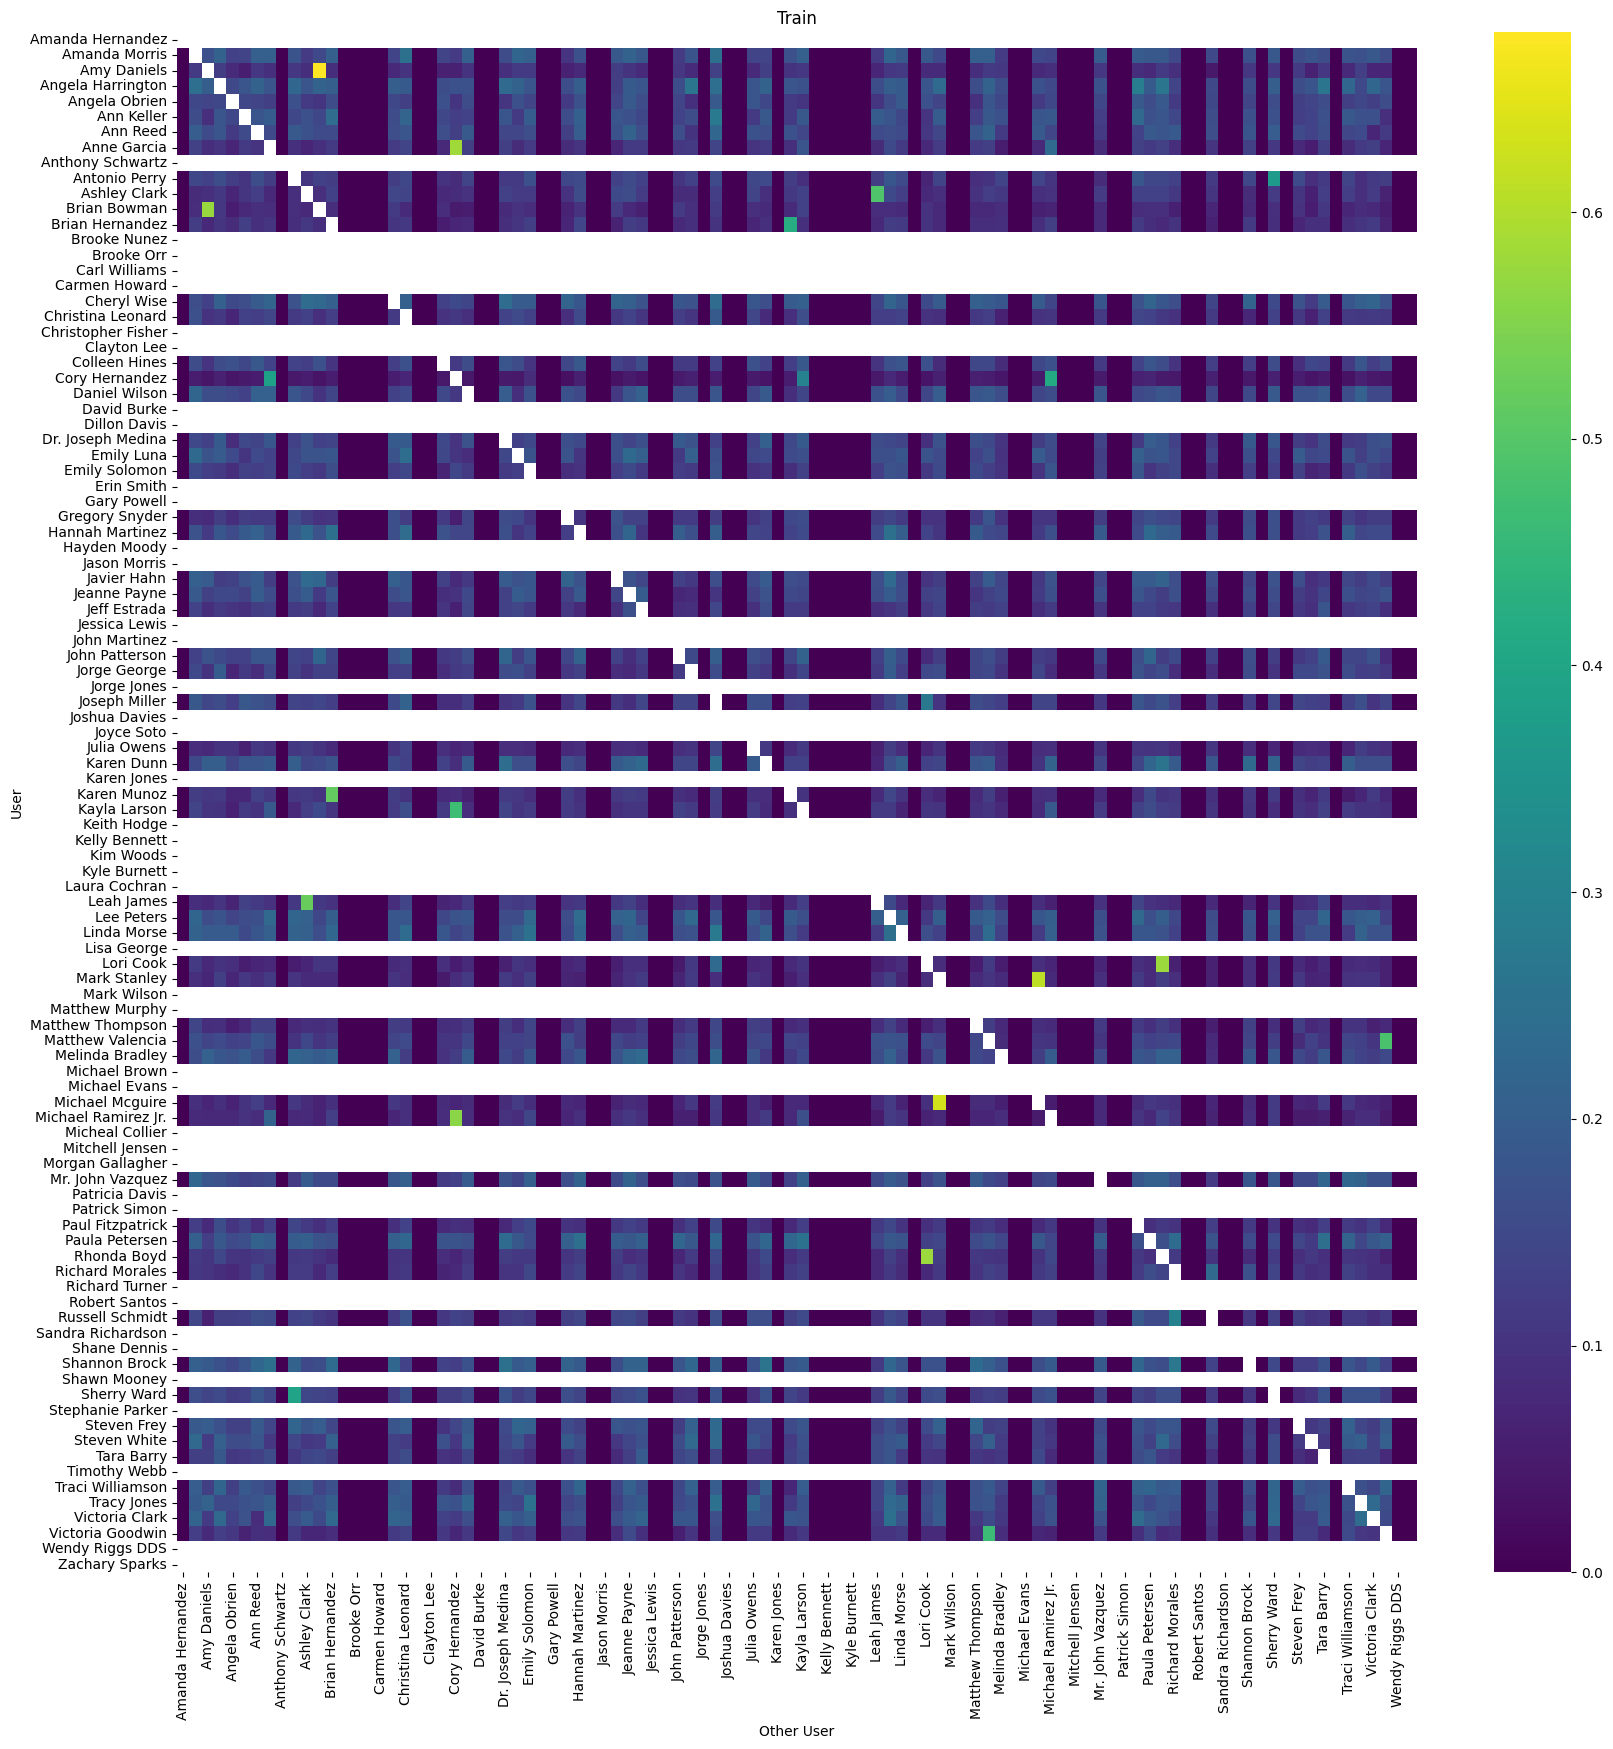

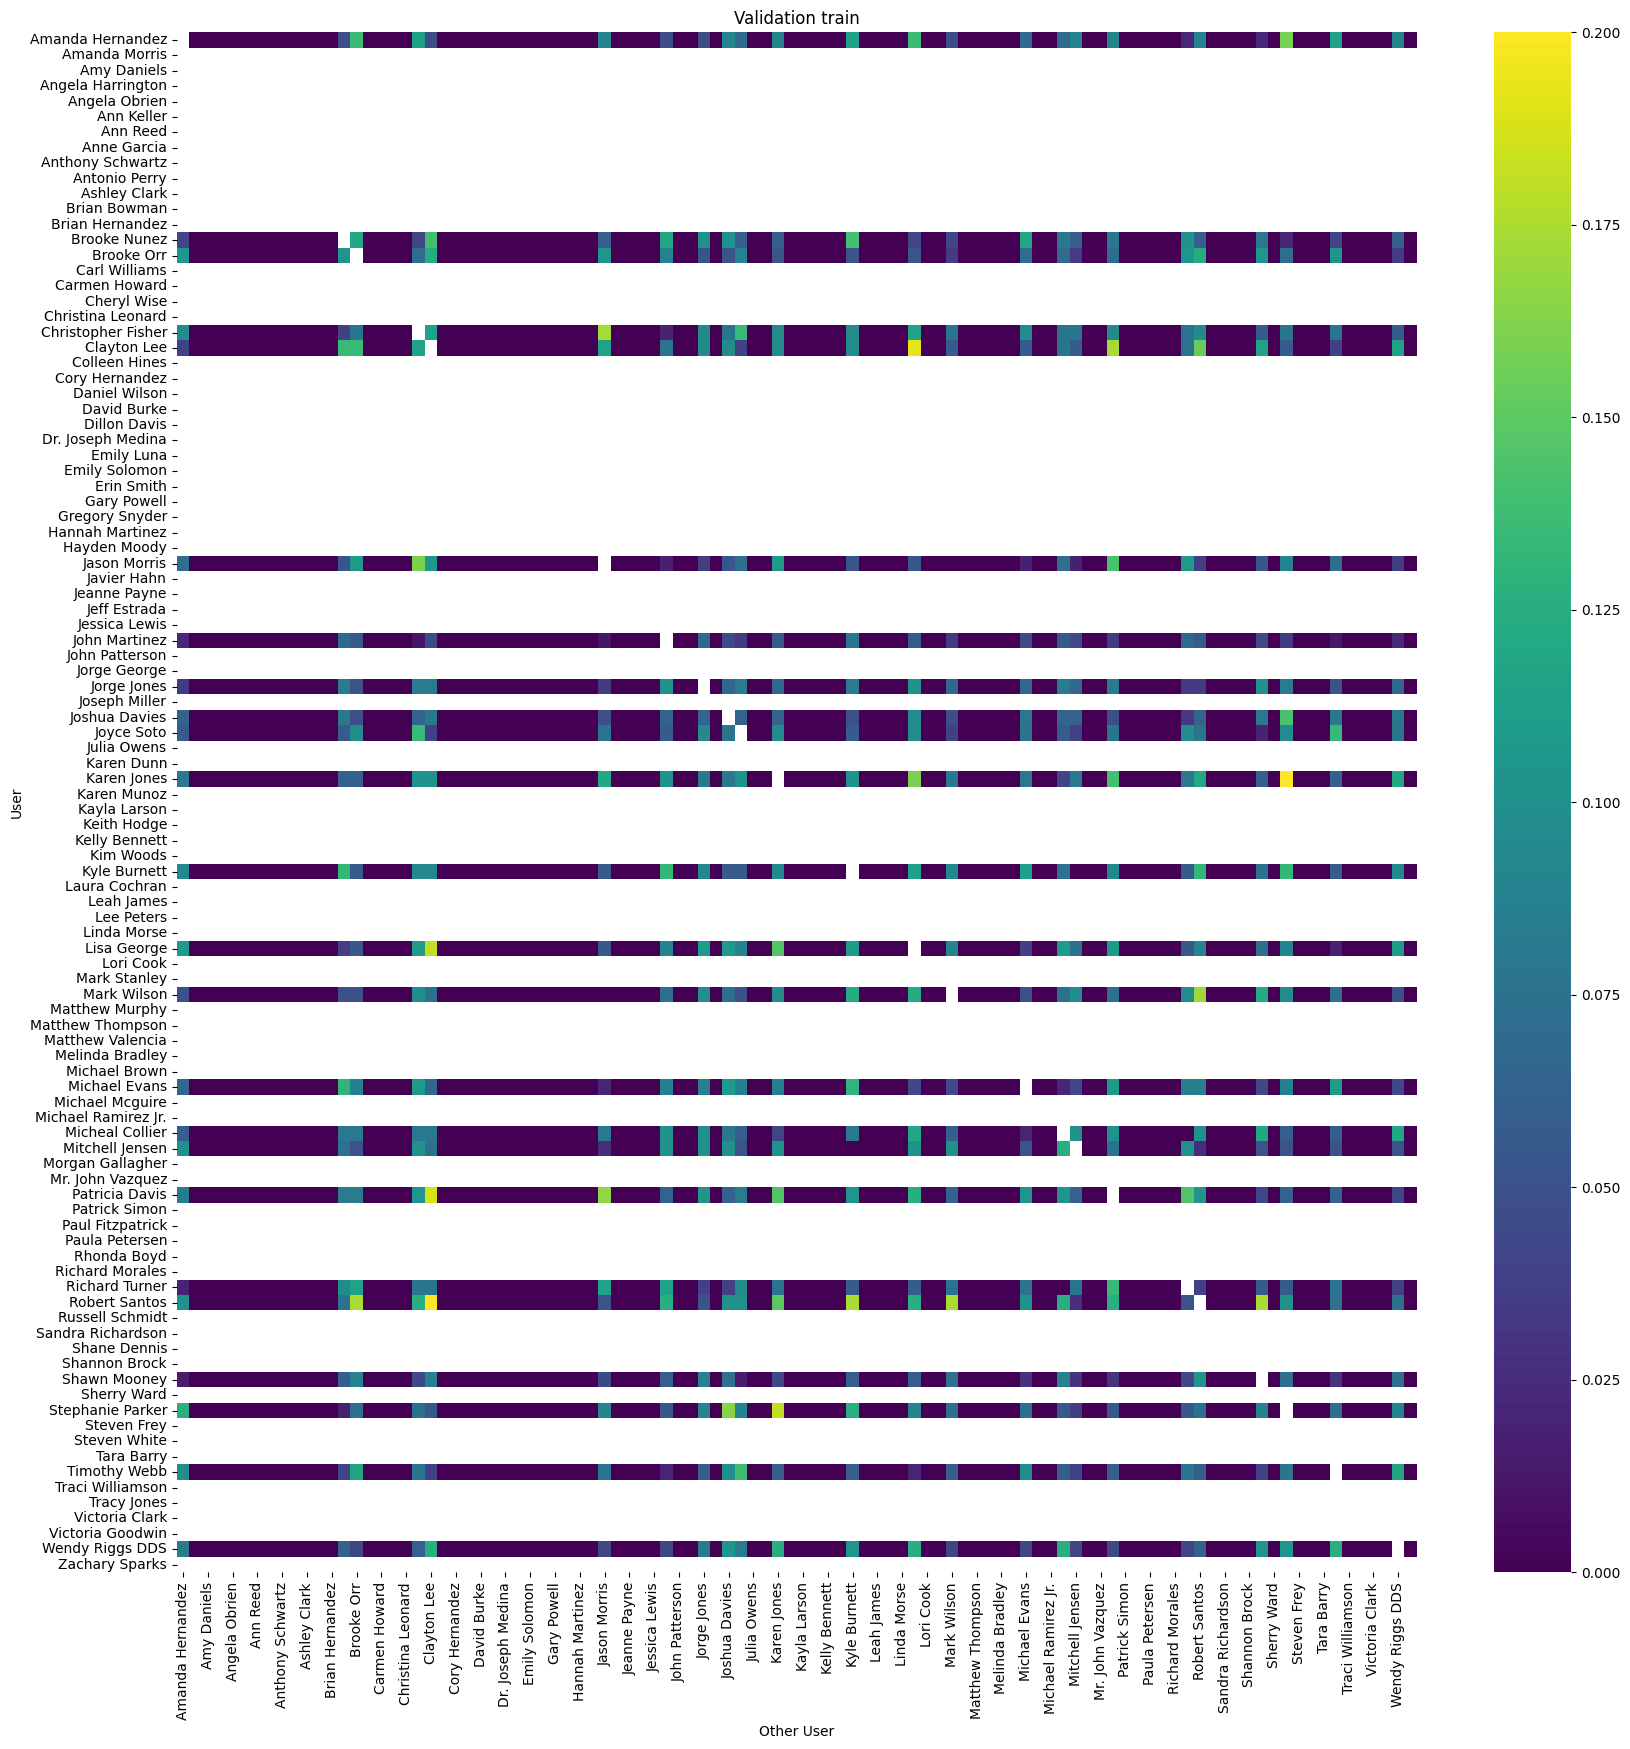

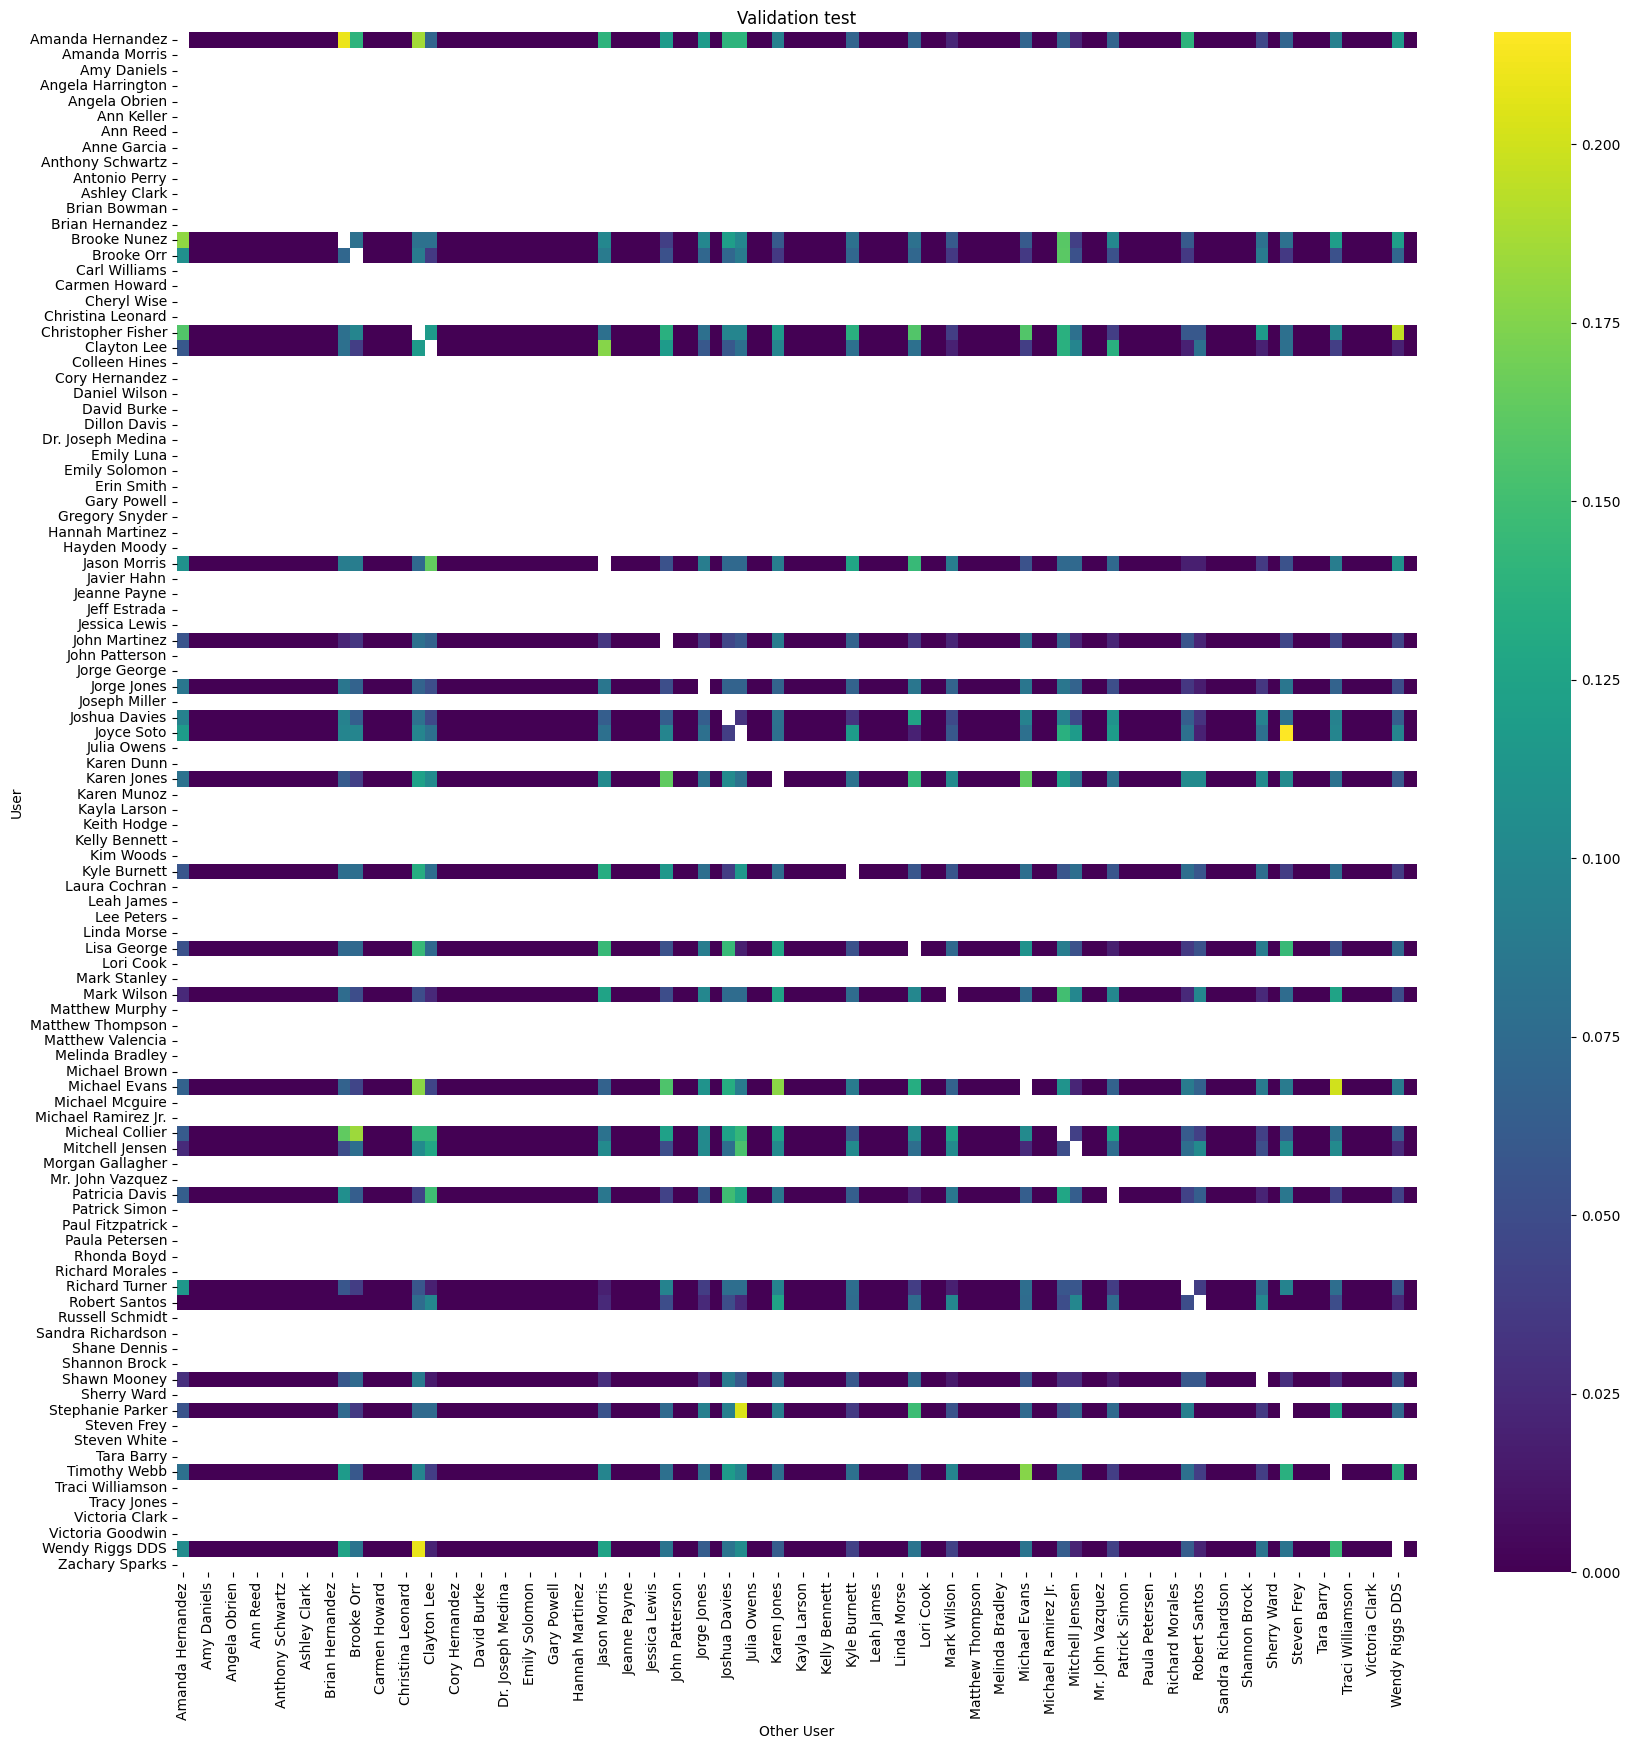

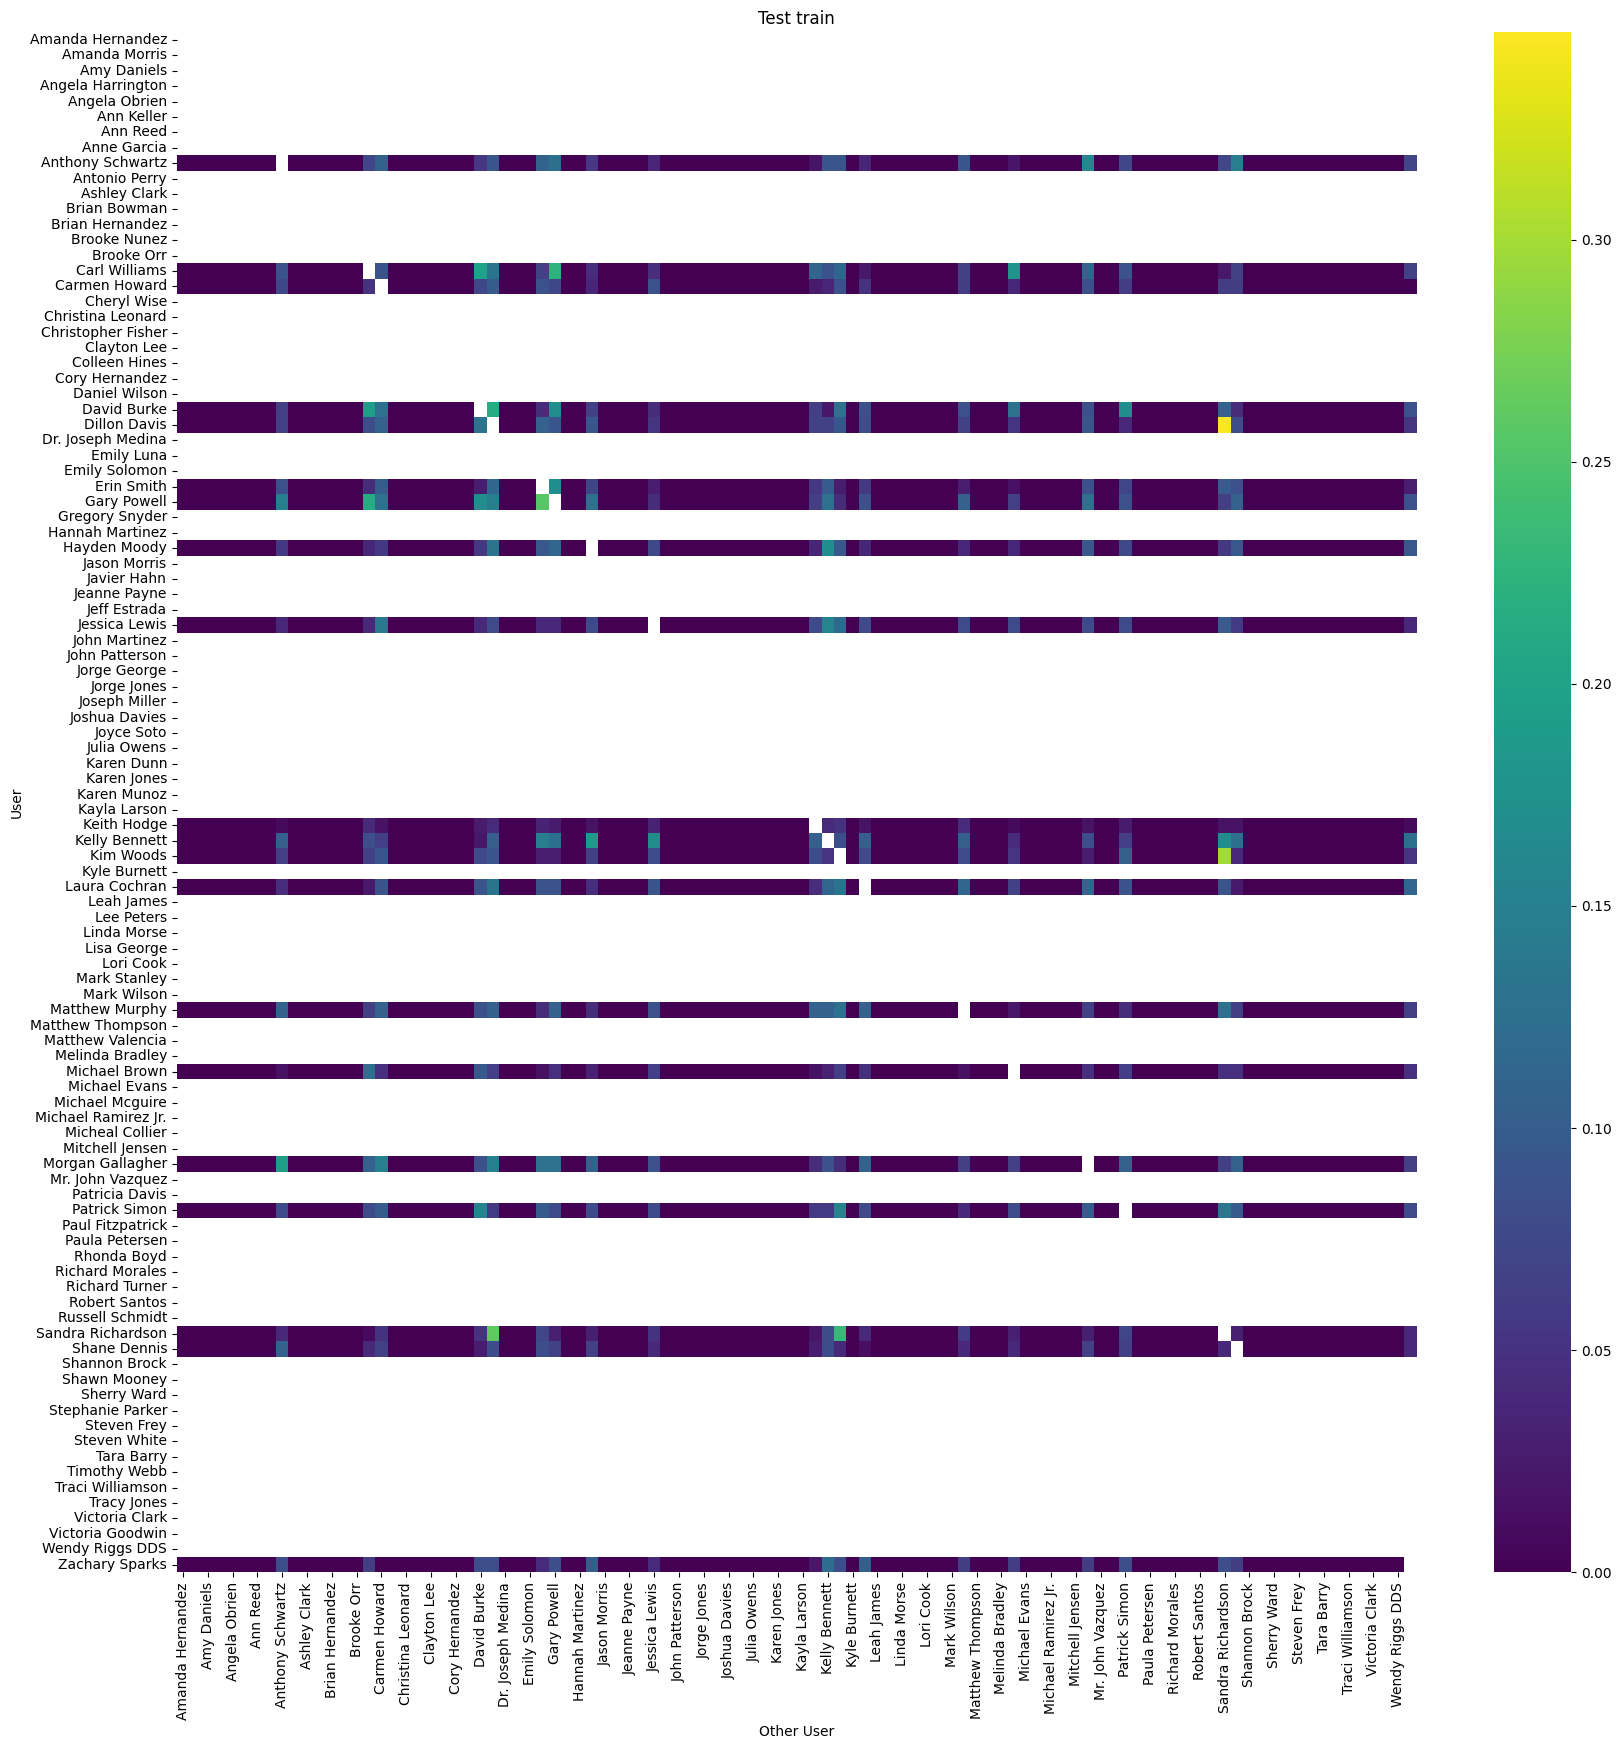

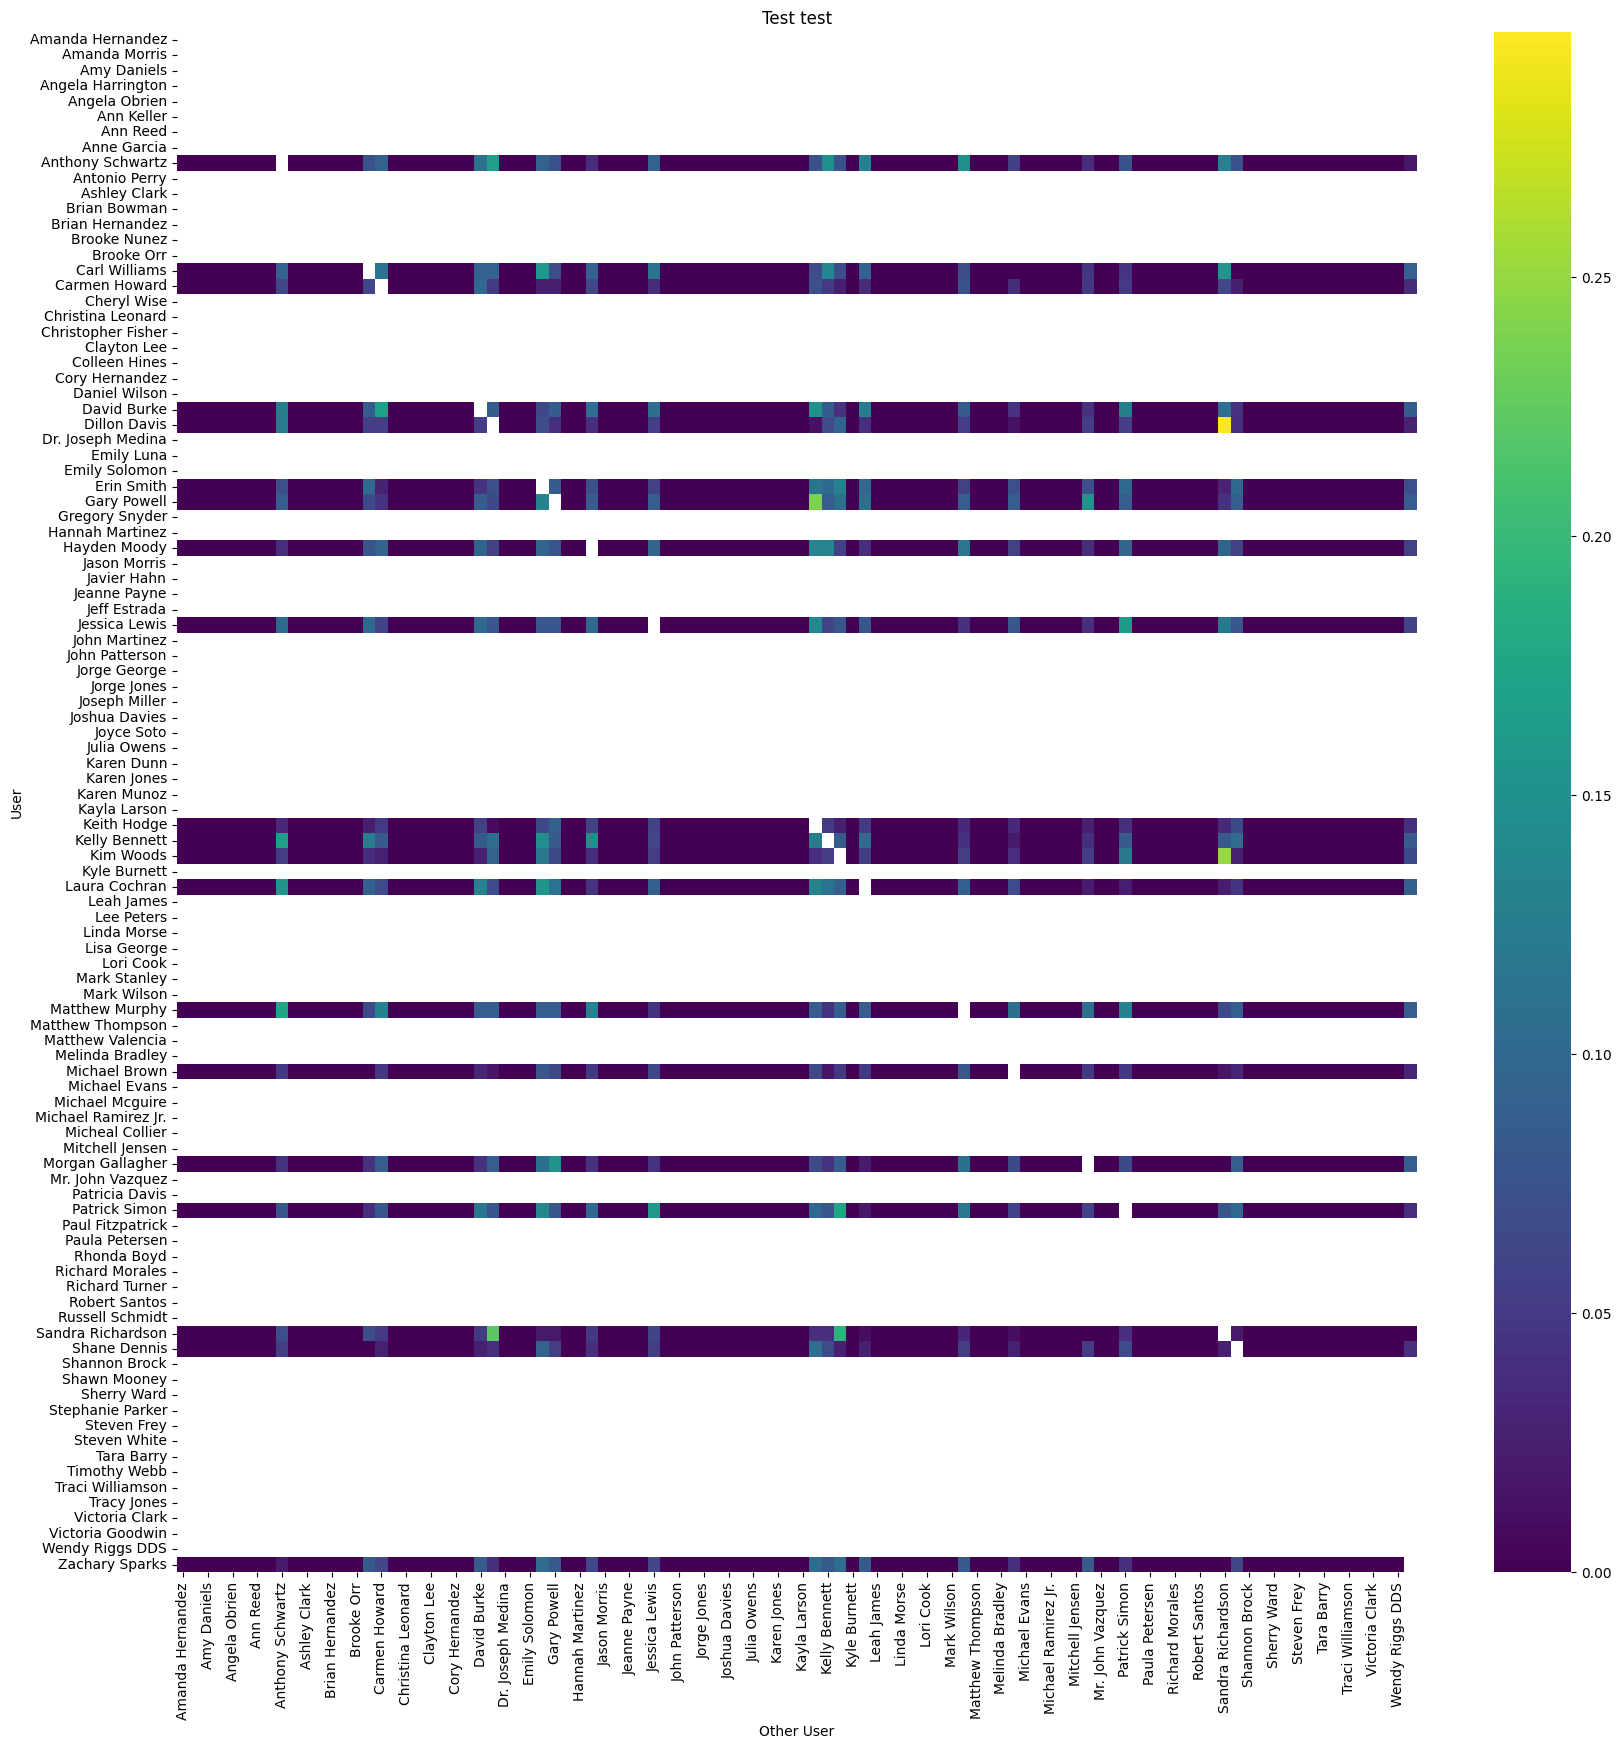

Alpha: 83.74730682373047
Min max affinity: 0.0 83.74730682373047
Min max affinity: 0.0 83.74730682373047
Min max affinity: 0.0 83.74730682373047
Min max affinity: 0.0 83.74730682373047
Min max affinity: 0.0 83.74730682373047
Min max affinity: 0.0 83.74730682373047
Max affinity: 83.74730682373047


In [11]:
train_df = df_matrix_mf_filtered[df_matrix_mf_filtered["username"].isin(train_df.index)]
# train_df["username"] = train_df["username"].cat.remove_unused_categories()
# train_df["id"] = train_df["id"].cat.remove_unused_categories()
print("Train data:")
display(train_df)

val_df_train, val_df_test = preprocessing.populate_train_test_dataframes(
    df=df_matrix_mf_filtered,
    selected_users=val_df,
    test_percentage=0.5,
    min_items_threshold=2,
)
# val_df_train["username"] = val_df_train["username"].cat.remove_unused_categories()
# val_df_test["username"] = val_df_test["username"].cat.remove_unused_categories()
# val_df_train["id"] = val_df_train["id"].cat.remove_unused_categories()
# val_df_test["id"] = val_df_test["id"].cat.remove_unused_categories()
print("Validation train data:")
display(val_df_train)
print("Validation test data:")
display(val_df_test)

test_df_train, test_df_test = preprocessing.populate_train_test_dataframes(
    df=df_matrix_mf_filtered,
    selected_users=test_df,
    test_percentage=0.5,
    min_items_threshold=2,
)
# test_df_train["username"] = test_df_train["username"].cat.remove_unused_categories()
# test_df_test["username"] = test_df_test["username"].cat.remove_unused_categories()
# test_df_train["id"] = test_df_train["id"].cat.remove_unused_categories()
# test_df_test["id"] = test_df_test["id"].cat.remove_unused_categories()
print("Test train data:")
display(test_df_train)
print("Test test data:")
display(test_df_test)

scaler = StandardScaler()
scaler.fit(train_df[spoti.NUMERICAL_FEATURES])
df_matrix_mf_filtered[spoti.NUMERICAL_FEATURES] = scaler.transform(df_matrix_mf_filtered[spoti.NUMERICAL_FEATURES])
train_df[spoti.NUMERICAL_FEATURES] = scaler.transform(train_df[spoti.NUMERICAL_FEATURES])
val_df_train[spoti.NUMERICAL_FEATURES] = scaler.transform(val_df_train[spoti.NUMERICAL_FEATURES])
val_df_test[spoti.NUMERICAL_FEATURES] = scaler.transform(val_df_test[spoti.NUMERICAL_FEATURES])
test_df_train[spoti.NUMERICAL_FEATURES] = scaler.transform(test_df_train[spoti.NUMERICAL_FEATURES])
test_df_test[spoti.NUMERICAL_FEATURES] = scaler.transform(test_df_test[spoti.NUMERICAL_FEATURES])

df_user_similarities = user_similarities.calculate_users_track_common_percentage(train_df, username_col="username", trackname_col="id")
plotting.plot_user_similarities_matrix(df_user_similarities, figsize=(20, 20), lower_triangle=False, title="Train")

df_user_similarities = user_similarities.calculate_users_track_common_percentage(val_df_train, username_col="username", trackname_col="id")
plotting.plot_user_similarities_matrix(df_user_similarities, figsize=(20, 20), lower_triangle=False, title="Validation train")

df_user_similarities = user_similarities.calculate_users_track_common_percentage(val_df_test, username_col="username", trackname_col="id")
plotting.plot_user_similarities_matrix(df_user_similarities, figsize=(20, 20), lower_triangle=False, title="Validation test")

df_user_similarities = user_similarities.calculate_users_track_common_percentage(test_df_train, username_col="username", trackname_col="id")
plotting.plot_user_similarities_matrix(df_user_similarities, figsize=(20, 20), lower_triangle=False, title="Test train")

df_user_similarities = user_similarities.calculate_users_track_common_percentage(test_df_test, username_col="username", trackname_col="id")
plotting.plot_user_similarities_matrix(df_user_similarities, figsize=(20, 20), lower_triangle=False, title="Test test")

(
    whole_matrix_dataset,
    train_matrix_dataset,
    validation_train_matrix_dataset,
    validation_test_matrix_dataset,
    test_train_matrix_dataset,
    test_test_matrix_dataset,
) = (
    MatrixDataset(
        df=df_matrix_mf_filtered,
        user_col="username",
        item_col="id",
        value_col="affinity",
        device=device,
        dtype=dtype,
    ),
    MatrixDataset(
        df=train_df,
        user_col="username",
        item_col="id",
        value_col="affinity",
        device=device,
        dtype=dtype,
    ),
    MatrixDataset(
        df=val_df_train,
        user_col="username",
        item_col="id",
        value_col="affinity",
        device=device,
        dtype=dtype,
    ),
    MatrixDataset(
        df=val_df_test,
        user_col="username",
        item_col="id",
        value_col="affinity",
        device=device,
        dtype=dtype,
    ),
    MatrixDataset(
        df=test_df_train,
        user_col="username",
        item_col="id",
        value_col="affinity",
        device=device,
        dtype=dtype,
    ),
    MatrixDataset(
        df=test_df_test,
        user_col="username",
        item_col="id",
        value_col="affinity",
        device=device,
        dtype=dtype,
    ),
)

a = whole_matrix_dataset.compute_alpha()
whole_matrix_dataset.set_alpha(a)
# min_scale, max_scale = whole_matrix_dataset.min_max_scale(bounds=(0.0, 1.0))

for dataset in [train_matrix_dataset, validation_train_matrix_dataset, validation_test_matrix_dataset, test_train_matrix_dataset, test_test_matrix_dataset]:
    dataset.set_alpha(a)
    # dataset.min_max_scale(bounds=(0.0, 1.0), optimums=(min_scale, max_scale))

print(f"Alpha: {a}")
print(f"Min max affinity: {whole_matrix_dataset.R.min().item()} {whole_matrix_dataset.R.max().item()}")
print(f"Min max affinity: {train_matrix_dataset.R.min().item()} {train_matrix_dataset.R.max().item()}")
print(f"Min max affinity: {validation_train_matrix_dataset.R.min().item()} {validation_train_matrix_dataset.R.max().item()}")
print(f"Min max affinity: {validation_test_matrix_dataset.R.min().item()} {validation_test_matrix_dataset.R.max().item()}")
print(f"Min max affinity: {test_train_matrix_dataset.R.min().item()} {test_train_matrix_dataset.R.max().item()}")
print(f"Min max affinity: {test_test_matrix_dataset.R.min().item()} {test_test_matrix_dataset.R.max().item()}")

max_affinity = whole_matrix_dataset.R.max().item()
print(f"Max affinity: {max_affinity}")

In [12]:
print("Whole dataset shape:", whole_matrix_dataset.R.shape)
print("Train dataset shape:", train_matrix_dataset.R.shape)
print("Validation train dataset shape:", validation_train_matrix_dataset.R.shape)
print("Validation test dataset shape:", validation_test_matrix_dataset.R.shape)
print("Test train dataset shape:", test_train_matrix_dataset.R.shape)
print("Test test dataset shape:", test_test_matrix_dataset.R.shape)

Whole dataset shape: torch.Size([100, 2665])
Train dataset shape: torch.Size([100, 2665])
Validation train dataset shape: torch.Size([100, 2665])
Validation test dataset shape: torch.Size([100, 2665])
Test train dataset shape: torch.Size([100, 2665])
Test test dataset shape: torch.Size([100, 2665])


In [13]:
whole_matrix_dataset.R

tensor([[ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000, 46.2574],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  2.2241],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        ...,
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000, 20.8379],
        [ 0.0000, 26.5252,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000, 43.5428]],
       device='mps:0')

In [14]:
train_dataset = TensorDataset(train_matrix_dataset.R)
validation_dataset = TensorDataset(validation_train_matrix_dataset.R, validation_test_matrix_dataset.R)
test_dataset = TensorDataset(test_train_matrix_dataset.R, test_test_matrix_dataset.R)

# Define and train the MultiVAE model

In [15]:
p_dims = [200, 600, whole_matrix_dataset.R.shape[1]]
model = MultiVAE(p_dims=p_dims).to(device=device, dtype=dtype)
model

MultiVAE(
  (q_layers): ModuleList(
    (0): Linear(in_features=2665, out_features=600, bias=True)
    (1): Linear(in_features=600, out_features=400, bias=True)
  )
  (p_layers): ModuleList(
    (0): Linear(in_features=200, out_features=600, bias=True)
    (1): Linear(in_features=600, out_features=2665, bias=True)
  )
  (drop): Dropout(p=0.5, inplace=False)
)

In [16]:
batch_size = 8
anneal_cap = 0.2
total_anneal_steps = 200000

optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=0)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
validation_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False)
(
    best_model,
    loss_history,
    validation_loss_history,
    ndcg_history,
    r20_history,
    r50_history,
    mpr_history,
    similarity_history,
) = model.train_model(
    optimizer,
    train_loader,
    num_epochs=50,
    anneal_cap=anneal_cap,
    total_anneal_steps=total_anneal_steps,
    device=device,
    dtype=dtype,
    validation_dataloader=validation_loader,
    validation_features_df=df_matrix_mf_filtered,
    validation_user_item_matrix=whole_matrix_dataset.R,
    validation_features_columns=spoti.NUMERICAL_FEATURES,
    log_interval=1,
    validation_similarity_max_item=100,
)

Epoch: 0 	 Loss: 11472.435547 	 Val Loss: 2063.155762 	 NDCG_100: 0.129439 	 Recall_20: 0.143750 	 Recall_50: 0.135205 	 MPR: 0.304379, 	 Similarity Score: 0.018109
Epoch: 1 	 Loss: 11388.171875 	 Val Loss: 1976.498291 	 NDCG_100: 0.168435 	 Recall_20: 0.200000 	 Recall_50: 0.183244 	 MPR: 0.286082, 	 Similarity Score: 0.016142
Epoch: 2 	 Loss: 10789.922852 	 Val Loss: 2008.222778 	 NDCG_100: 0.200098 	 Recall_20: 0.202083 	 Recall_50: 0.192194 	 MPR: 0.273512, 	 Similarity Score: 0.015052
Epoch: 3 	 Loss: 11077.411133 	 Val Loss: 1997.155762 	 NDCG_100: 0.183724 	 Recall_20: 0.197917 	 Recall_50: 0.176516 	 MPR: 0.275947, 	 Similarity Score: 0.016304
Epoch: 4 	 Loss: 11056.175781 	 Val Loss: 1998.139648 	 NDCG_100: 0.201466 	 Recall_20: 0.212500 	 Recall_50: 0.194039 	 MPR: 0.273598, 	 Similarity Score: 0.016986
Epoch: 5 	 Loss: 10602.814453 	 Val Loss: 1992.169800 	 NDCG_100: 0.182102 	 Recall_20: 0.187500 	 Recall_50: 0.186744 	 MPR: 0.268538, 	 Similarity Score: 0.020436
Epoch: 6 	

KeyboardInterrupt: 

In [ ]:
losses_df = pd.DataFrame([loss_history, validation_loss_history, ndcg_history, r20_history, r50_history, mpr_history, similarity_history]).T
losses_df.columns = ["loss", "validation_loss", "ndgk", "r20", "r50", "mpr", "similarity"]

px.line(losses_df, x=losses_df.index, y=["loss", "validation_loss"], title="Loss").show()
px.line(losses_df, x=losses_df.index, y=["ndgk", "r20", "r50", "mpr", "similarity"], title="Metrics").show()

In [ ]:
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)
total_loss, ndcg, recall_20, recall_50, mpr, similarity = best_model.evaluate_model(
    test_loader,
    anneal_cap=anneal_cap,
    total_anneal_steps=total_anneal_steps,
    df_features=df_matrix_mf_filtered,
    user_item_matrix=whole_matrix_dataset.R,
    features_columns=spoti.NUMERICAL_FEATURES,
    device=device,
    dtype=dtype,
)
print(f"Total loss: {total_loss}")
print(f"NDCG_100: {ndcg}")
print(f"Recall_20: {recall_20}")
print(f"Recall_50: {recall_50}")
print(f"MPR: {mpr}")
print(f"Similarity: {similarity}")

Total loss: 179.91336681374483
NDCG_100: 0.07857616245746613
Recall_20: 0.125
Recall_50: 0.21090909838676453
MPR: 0.4611921012401581
Similarity: -0.004182323347777128


In [ ]:
# retrieve users latent representations (mean and variance)
user_names = df_matrix_mf["username"].sort_values().unique().tolist()
user_names

['daniel', 'larry', 'meagan', 'sean', 'timothy', 'todd', 'virginia']

In [ ]:
z, mu, std, logvar = best_model.get_latent_representations(whole_matrix_dataset.R)

print(z.shape)
print(mu.shape)
print(std.shape)
print(logvar.shape)

torch.Size([7, 200])
torch.Size([7, 200])
torch.Size([7, 200])
torch.Size([7, 200])


In [ ]:
# Define the number of points for grid, the width of the gaussian curves and color map
# dim1 = range(0, p_dims[0])
# dim2 = range(0, p_dims[0])
dim1 = range(10, 15)
dim2 = range(10, 15)

# for i in dim1:
#     for j in dim2:
#         if i >= j:
#             continue
#         # # Plot 2D latent space using and add annotations with usernames
#         # fig = px.scatter(x=z[:, i], y=z[:, j], hover_name=usersnames, color=usersnames)
#         # fig.update_traces(marker=dict(size=10))
#         # fig.update_layout(title="2D Latent Space")
#         # # Show the usernames next to the points
#         # for i_username, username in enumerate(usersnames):
#         #     fig.add_annotation(
#         #         x=z[i_username, i], y=z[i_username, j], text=username, showarrow=False, xshift=-20, yshift=15
#         #     )
#         # fig.show()
        
#         # Using sns
#         fig, ax = plt.subplots(figsize=(10, 5))
#         sns.scatterplot(x=z[:, i], y=z[:, j], hue=usersnames, ax=ax)
#         for i_username, username in enumerate(usersnames):
#             ax.text(z[i_username, i], z[i_username, j] + 0.3, username, fontsize=8)
#         ax.set_title(f"2D Latent Space ({i}, {j})")
#         ax.set_xlabel(f"z{i}")
#         ax.set_ylabel(f"z{j}")
#         plt.show()

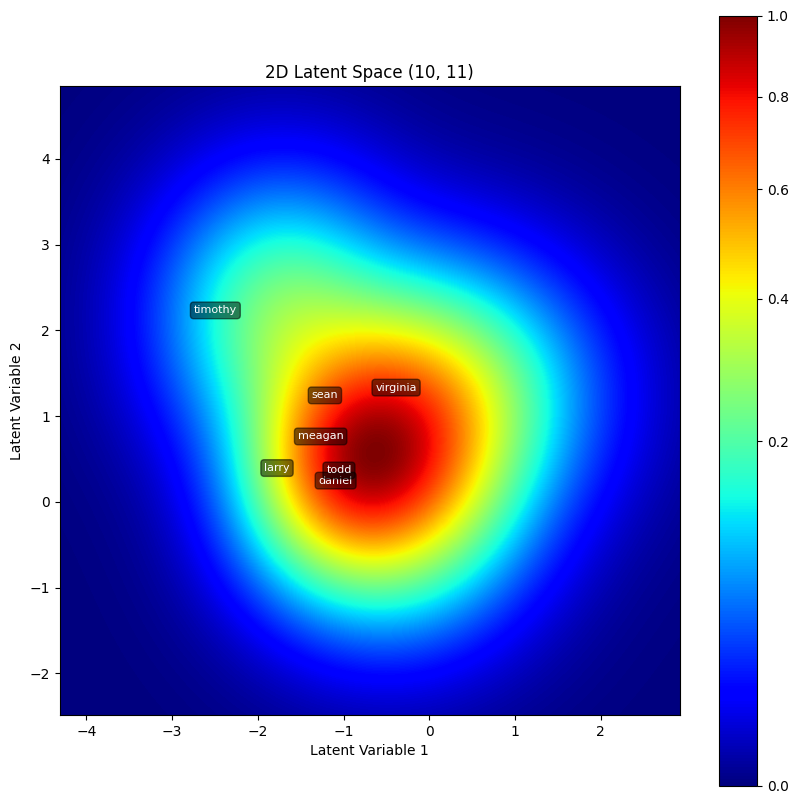

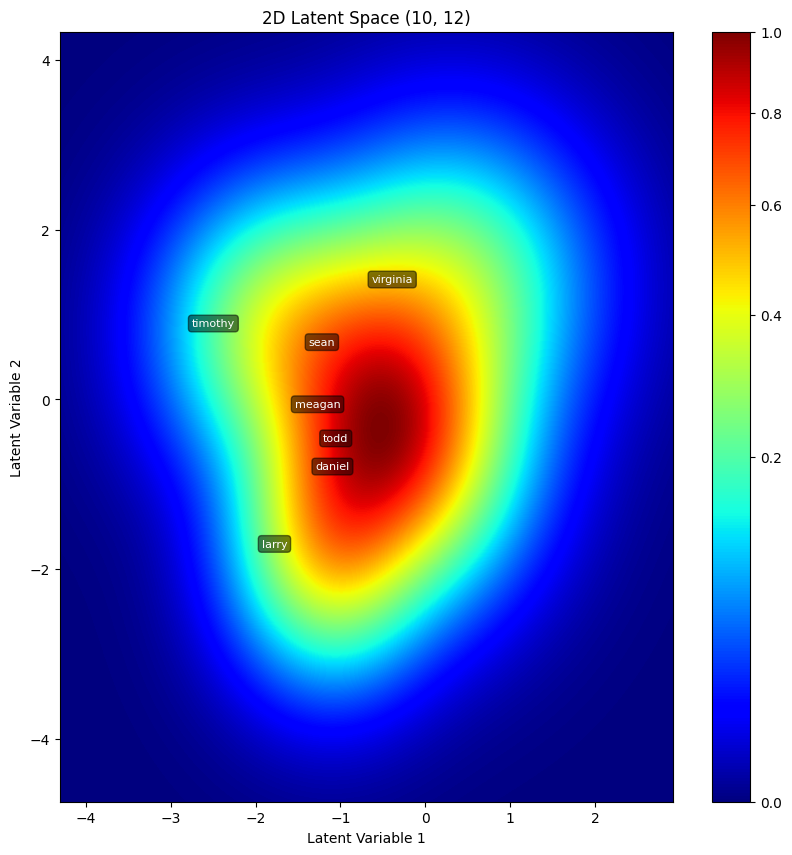

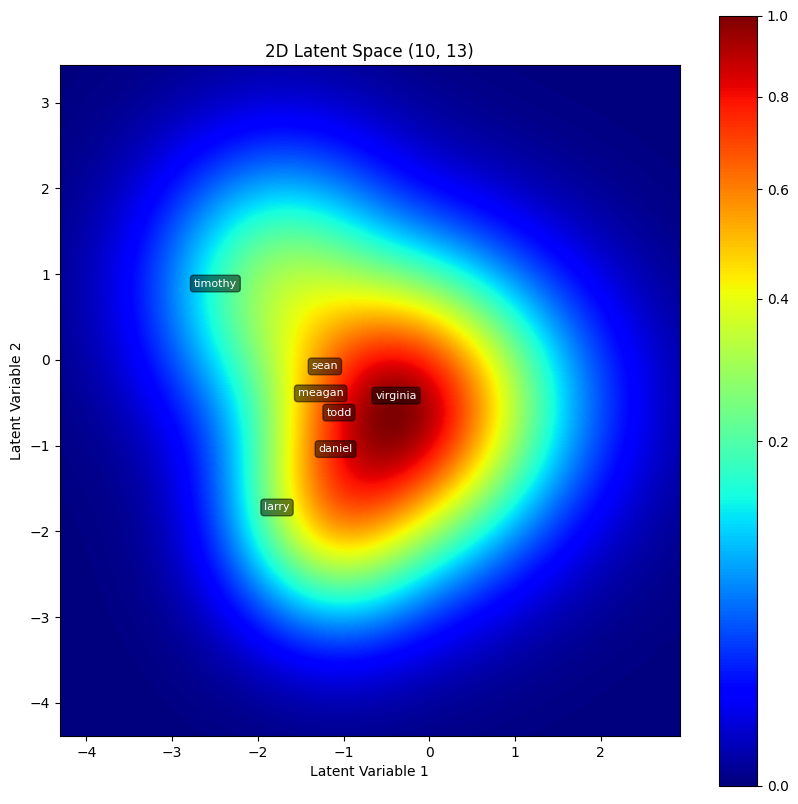

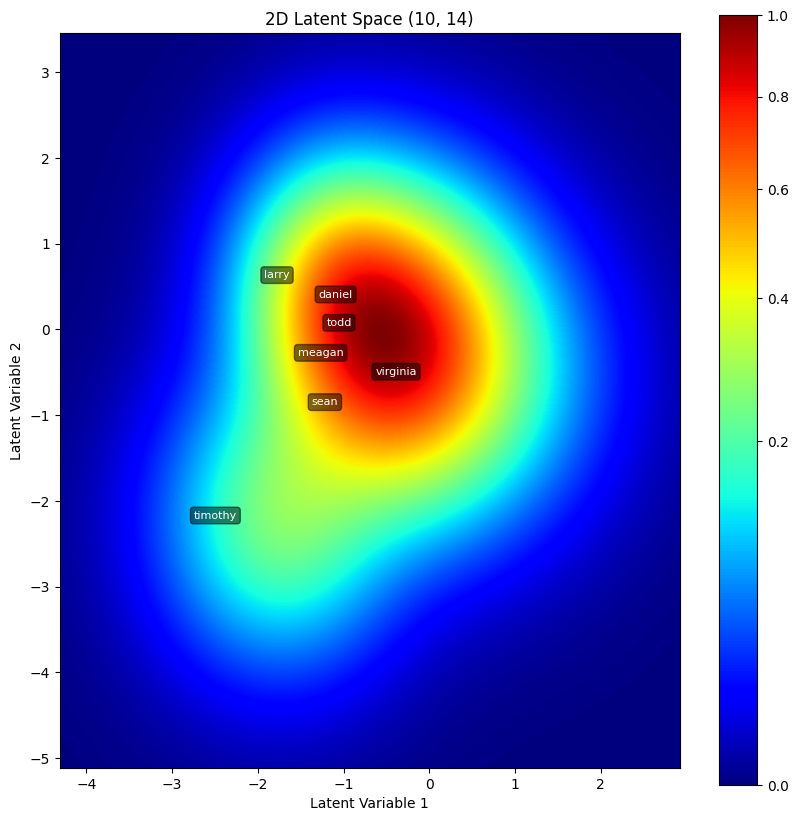

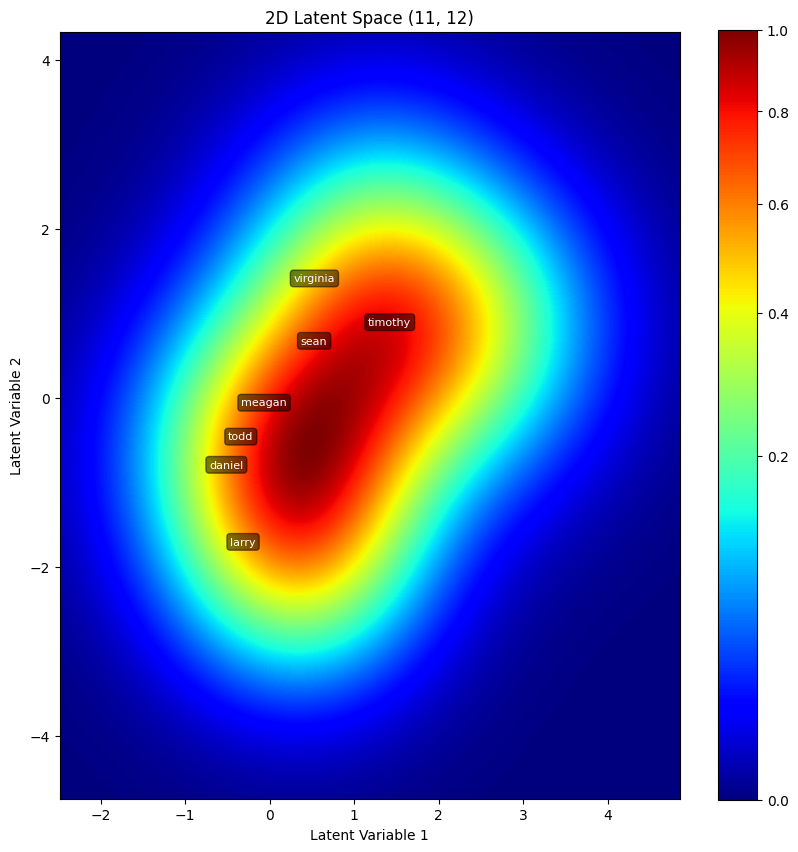

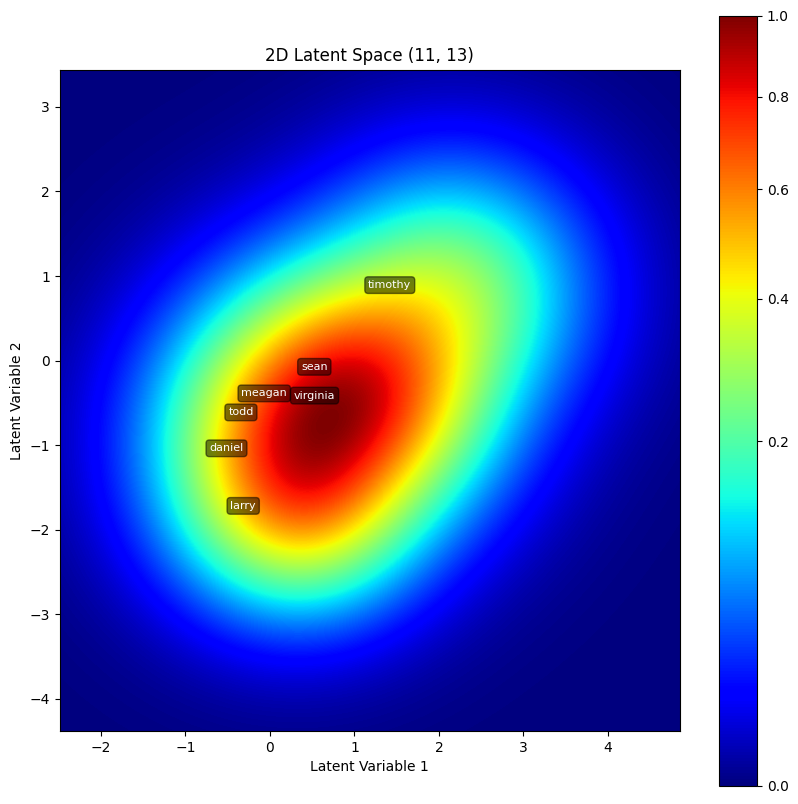

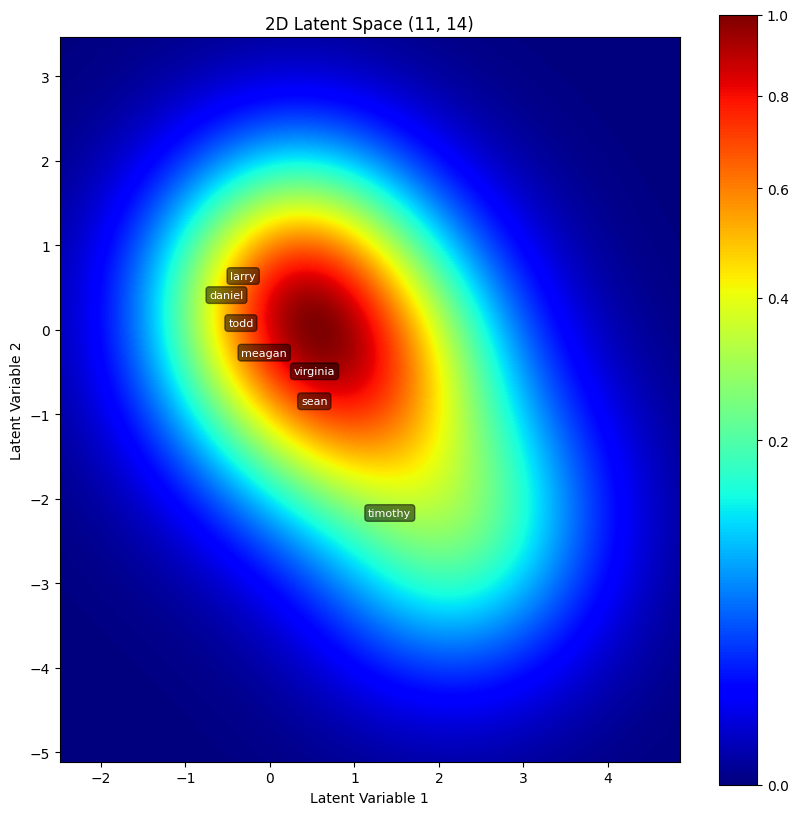

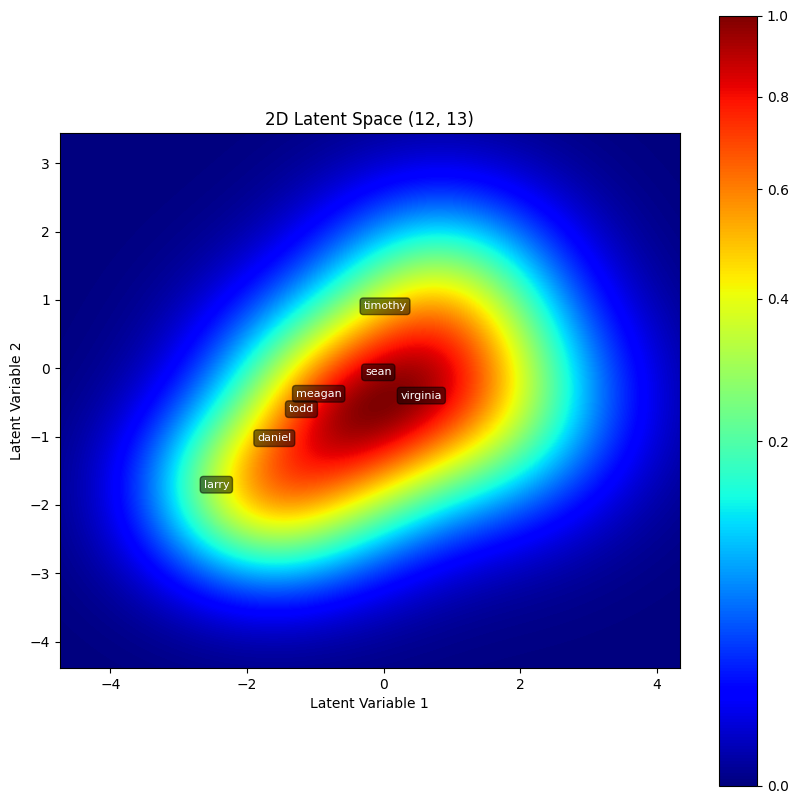

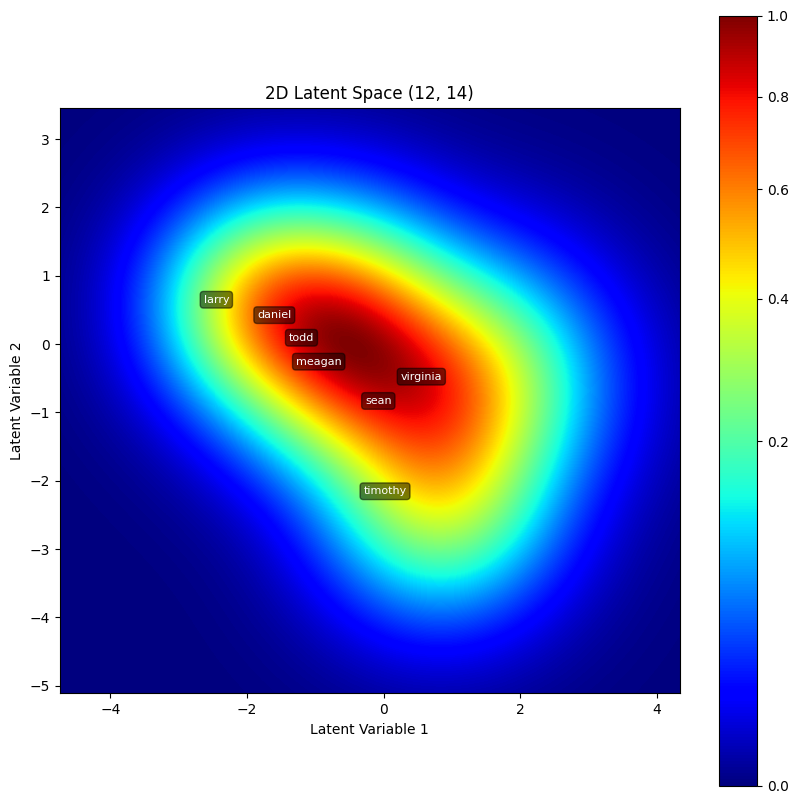

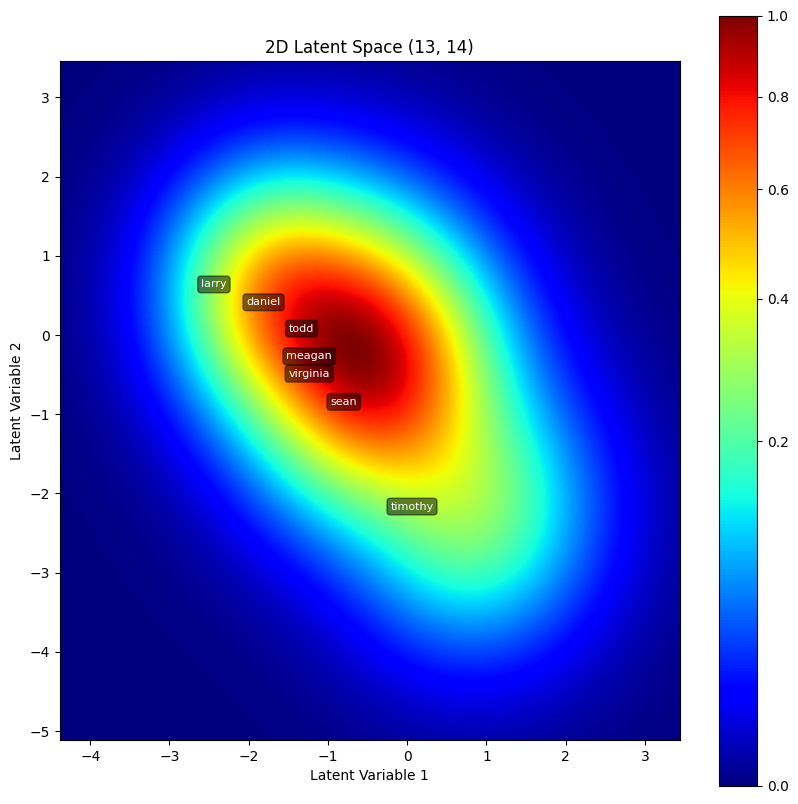

In [ ]:
for i in dim1:
    for j in dim2:
        if i >= j:
            continue
        plotting.plot_multivariate_gaussian_image_with_labels(
            mu.cpu().numpy()[:, [i, j]],
            std.cpu().numpy()[:, [i, j]],
            color_map="jet",
            # dpi=300,
            labels=user_names,
            title=f"2D Latent Space ({i}, {j})",
        )

In [ ]:
username = "timothy"
user_id = whole_matrix_dataset.usernames_to_ids([username])[0]
username = whole_matrix_dataset.ids_to_usernames([user_id])[0]
print(f"User id: {user_id}, {username}")
user_seen = whole_matrix_dataset.get_interactions_ids(user_id)
user_seen.cpu().numpy().shape

User id: 4, timothy


(111,)

In [ ]:
user_seen.cpu().numpy()

array([  0,   1,   2,   4,   5,   6,   8,   9,  12,  15,  17,  20,  21,
        23,  25,  28,  30,  37,  52,  54,  57,  60,  64,  69,  72,  80,
        83,  90,  94, 101, 102, 105, 106, 108, 110, 114, 116, 117, 120,
       121, 122, 123, 125, 129, 131, 132, 135, 136, 141, 142, 143, 144,
       145, 146, 148, 151, 157, 158, 159, 162, 163, 166, 167, 173, 176,
       179, 182, 184, 191, 192, 195, 196, 198, 201, 203, 206, 207, 208,
       211, 213, 215, 217, 228, 231, 233, 235, 237, 242, 243, 249, 256,
       257, 263, 266, 268, 271, 273, 274, 285, 289, 296, 299, 301, 303,
       306, 309, 310, 311, 313, 322, 323])

In [ ]:
similar_users_ids = best_model.sort_similar_users(user_id=user_id, latent_representations=z)
most_similar_users = whole_matrix_dataset.ids_to_usernames(similar_users_ids.cpu().numpy())[1:]
most_similar_users

['sean', 'meagan', 'todd', 'larry', 'virginia', 'daniel']

In [ ]:
items_ids, predicted_scores = best_model.recommend(matrix=whole_matrix_dataset.R)
recommendation_df: pd.DataFrame = whole_matrix_dataset.df.copy()
recommendation_df["item_id"] = recommendation_df["id"].cat.codes.astype("int")
recommendation_df.set_index("item_id", inplace=True)

# Get df in the same order as the ids
recommendation_df = recommendation_df.loc[items_ids.cpu().numpy()[user_id]]
recommendation_df["predicted_scores"] = pd.Series(predicted_scores.cpu().numpy()[user_id], index=items_ids.cpu().numpy()[user_id])

recommendation_df = recommendation_df[recommendation_df["username"] != username]
recommendation_df = recommendation_df.drop_duplicates(subset=["username", "id"])
recommendation_df["seen"] = recommendation_df.index.isin(user_seen.cpu().numpy())
# recommendation_df = recommendation_df[recommendation_df["seen"] == False]
recommendation_df = recommendation_df.drop_duplicates(subset=["id"])
recommendation_df = recommendation_df.sort_values(by="predicted_scores", ascending=False)

columns = spoti.PRETTY_PRINT_FEATURES
columns = list(recommendation_df.columns)
recommendation_df[["id", "predicted_scores", "seen"] + columns].head(30)[spoti.PRETTY_PRINT_FEATURES]

,username,artists_names,name,release_year,popularity,danceability,energy,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,loudness,duration_ms,release_year,time_signature,popularity
item_id,,,,,,,,,,,,,,,,,,,
323,sean,A$AP Rocky,Praise The Lord (Da Shine) (feat. Skepta),0.576820,1.008449,1.255341,-0.281163,-0.997308,-0.006672,-0.732745,0.074412,-0.517108,-0.818473,-1.485858,-0.117233,-0.321661,0.576820,0.236124,1.008449
101,larry,Damso,MEVTR,0.797287,-1.219513,-0.185131,0.080063,1.002699,0.832554,-0.382593,-0.348526,0.440065,-0.438812,0.522802,0.359123,-0.793547,0.797287,0.236124,-1.219513
184,larry,Josman,L'Occasion,0.576820,-1.002151,0.909377,-0.160754,1.002699,2.256695,0.033466,-0.349404,-0.384816,1.079830,-1.263661,0.527879,-0.105409,0.576820,0.236124,-1.002151
145,larry,Josman,XS,0.576820,0.030319,0.959699,0.682106,-0.997308,0.544335,0.324339,-0.349404,-0.636950,0.270791,0.928480,0.838300,-0.299627,0.576820,0.236124,0.030319
21,meagan,S-Crew,22,0.870776,-0.513086,1.274212,-0.692559,1.002699,-0.262678,-0.065946,-0.349392,-0.275869,-1.822765,0.299118,-0.059946,-0.365197,0.870776,0.236124,-0.513086
2,larry,R3HAB,All Around The World (La La La),0.650309,0.573725,0.494219,1.173775,-0.997308,-0.625495,0.806672,-0.014402,-0.478199,0.202995,0.183709,0.763517,-1.000753,0.650309,0.236124,0.573725
37,sean,Roddy Ricch,The Box,0.650309,1.117130,1.519533,-0.195874,-0.997308,-0.431371,-0.574053,-0.349404,4.852404,0.754407,-0.112691,0.295910,-0.421246,0.650309,0.236124,1.117130
243,larry,Dinos,93 mesures,0.723798,-0.458745,1.286793,-0.481844,-0.997308,1.883706,-0.778401,-0.349404,-0.544345,-0.786834,-0.892427,-0.610521,0.399529,0.723798,0.236124,-0.458745
20,meagan,Pop Smoke,For The Night (feat. Lil Baby & DaBaby),0.723798,0.791087,1.060343,-0.195874,-0.997308,0.790169,-0.537234,-0.349404,0.206608,-0.578925,0.221720,0.318768,-0.494569,0.723798,0.236124,0.791087
